In [39]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from PIL import Image
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import kneighbors_graph
import networkx as nx
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, KFold
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.utils import class_weight
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

from tensorflow.keras import backend as K
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV


In [2]:

def process_images_in_folder(folder_path, cell_type, target_size=(100, 100)):
    """
    Converts a folder of images into a pandas DataFrame. 
    Images are convereted to RGB.
    Images are resized.
    Image arrays are normalized and flattened by dividing by 255.

    Args:
        folder_path (str): The path to the folder containing images.
        cell_type (str): The label/category for this folder of images.
        target_size (tuple): The desired size for each image (width, height).

    Returns:
        pandas.DataFrame: A DataFrame with columns for cell_type and normalized image data.
    """
    data = []
    processed_count = 0
    error_count = 0
    
    # Check if the folder exists
    if not os.path.isdir(folder_path):
        print(f"Error: Folder not found at {folder_path}")
        return pd.DataFrame()

    # Iterate over every file in the folder
    for filename in os.listdir(folder_path):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
            file_path = os.path.join(folder_path, filename)
            
            try:
                # Open the image file
                with Image.open(file_path) as img:
                    # Ensure RGB format (since preprocessing converted to RGB)
                    if img.mode != 'RGB':
                        img = img.convert('RGB')
                    
                    # Resize the image using high-quality resampling
                    img_resized = img.resize(target_size, Image.LANCZOS)
                    img_array = np.array(img_resized, dtype=np.float32)
                    
                    # Normalize pixel values to [0, 1] range
                    img_array_normalized = img_array / 255.0
                    
                    # Flatten the array to a single row for the DataFrame
                    img_array_flat = img_array_normalized.flatten()
                    
                    # Store normalized image data with cell type label
                    data.append({
                        'cell_type': cell_type,
                        'img_data': img_array_flat
                    })
                    processed_count += 1
                    
            except Exception as e:
                print(f"Skipping file {filename} due to error: {e}")
                error_count += 1
   
    # Create the pandas DataFrame
    df = pd.DataFrame(data)
    
    # Print summary statistics
    print(f"Processed {processed_count} images from {cell_type} folder")
    if error_count > 0:
        print(f"Encountered {error_count} errors")
    
    return df




In [3]:
# Main processing code
cell_types = [
    'basophil',
    'eosinophil',
    'Ig',
    'lymphocyte',
    'monocyte',
    'neutrophil'
]

# Debug: Check current working directory and available paths
print(f"Current working directory: {os.getcwd()}")
print("Looking for folders...")

# Check different possible path structures
possible_base_paths = [
    "Train_alteredRBG",  # If Train_altered is in current directory
    os.path.join("Data", "Train_alteredRBG"),  # If Data folder is in current directory
    os.path.join("..", "Data", "Train_alteredRBG"),  # Original path
    os.path.join("..", "Train_alteredRBG"),  # If Train_altered is one level up
]

# Find the correct base path
base_path = None
for path in possible_base_paths:
    if os.path.exists(path):
        base_path = path
        print(f"Found base path: {base_path}")
        break

if base_path is None:
    print("Error: Could not find Train_altered folder in any expected location")
    print("Available directories in current folder:")
    for item in os.listdir("."):
        if os.path.isdir(item):
            print(f"  - {item}")
    
    # Check parent directory
    parent_dir = ".."
    if os.path.exists(parent_dir):
        print("Available directories in parent folder:")
        for item in os.listdir(parent_dir):
            if os.path.isdir(os.path.join(parent_dir, item)):
                print(f"  - {item}")
else:
    # Proceed with processing if base path is found
    all_dataframes = []  # More efficient than repeatedly concatenating

    for cell_type in cell_types:
        # Use the found base path
        folder_path = os.path.join(base_path, cell_type)
        print(f"Processing {cell_type} folder at: {folder_path}")
        
        # Check if specific cell type folder exists
        if os.path.exists(folder_path):
            df = process_images_in_folder(folder_path, cell_type)
            
            if not df.empty:  # Only add non-empty DataFrames
                all_dataframes.append(df)
                print(f"Added {len(df)} images from {cell_type}")
            else:
                print(f"Warning: No images found in {cell_type} folder")
        else:
            print(f"Warning: Folder {folder_path} does not exist")

    # Combine all DataFrames at once (more efficient)
    if all_dataframes:
        all_cells_df = pd.concat(all_dataframes, ignore_index=True)
        print(f"\nTotal dataset created with {len(all_cells_df)} images")
        
        # Display basic info about the dataset
        print(f"Dataset shape: {all_cells_df.shape}")
        print(f"Cell type distribution:")
        print(all_cells_df['cell_type'].value_counts())
        
        # Example: View the first few rows
        print("\nFirst few rows:")
        print(all_cells_df.head())
        
    else:
        print("Warning: No data found in any folders")
        all_cells_df = pd.DataFrame()
        print("No data to display")


Current working directory: c:\Users\goatf\Documents\Springboard\Capstone_3\Notebooks
Looking for folders...
Found base path: ..\Data\Train_alteredRBG
Processing basophil folder at: ..\Data\Train_alteredRBG\basophil
Processed 1218 images from basophil folder
Added 1218 images from basophil
Processing eosinophil folder at: ..\Data\Train_alteredRBG\eosinophil
Processed 3117 images from eosinophil folder
Added 3117 images from eosinophil
Processing Ig folder at: ..\Data\Train_alteredRBG\Ig
Processed 2895 images from Ig folder
Added 2895 images from Ig
Processing lymphocyte folder at: ..\Data\Train_alteredRBG\lymphocyte
Processed 1214 images from lymphocyte folder
Added 1214 images from lymphocyte
Processing monocyte folder at: ..\Data\Train_alteredRBG\monocyte
Processed 1420 images from monocyte folder
Added 1420 images from monocyte
Processing neutrophil folder at: ..\Data\Train_alteredRBG\neutrophil
Processed 3328 images from neutrophil folder
Added 3328 images from neutrophil

Total dat

In [5]:
all_cells_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13192 entries, 0 to 13191
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   cell_type  13192 non-null  object
 1   img_data   13192 non-null  object
dtypes: object(2)
memory usage: 206.3+ KB


all_cells_df is made of scaled RBG cell images

With this pandas data frame we will try the Knearest neighbor model. The train set will be stratified becasue some photos have different quantities.

In [26]:
X = np.stack(all_cells_df['img_data'].values)
y = all_cells_df['cell_type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

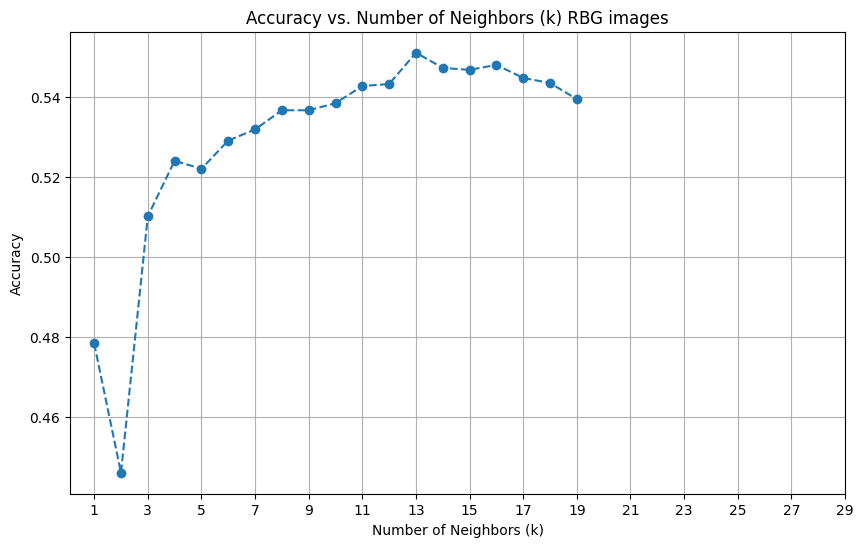

In [27]:
k_values = range(1, 20)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linestyle='--')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Number of Neighbors (k) RBG images')
plt.xticks(np.arange(1, 31, 2))
plt.grid(True)
plt.show()

it looks like the best KNN is 13

In [28]:
# 3. Create and train the nearest neighbor model
# We create a KNeighborsClassifier with a specified number of neighbors
nk=13
knn = KNeighborsClassifier(n_neighbors=nk)
knn.fit(X_train, y_train)

,n_neighbors,13
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [29]:
# Perform K-Fold cross validation on knn model

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(knn, X, y, cv=kf, scoring='accuracy')

print(f"k fold Accuracy Score: {cv_scores.mean():.4f}")
print(f"K-Fold Standard Deviation: {cv_scores.std():.4f}") 

k fold Accuracy Score: 0.5585
K-Fold Standard Deviation: 0.0151


In [30]:
# evaluating the model with the test set
y_pred = knn.predict(X_test)
print("Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=cell_types))

Model Evaluation:
Accuracy: 0.5510

Classification Report:
              precision    recall  f1-score   support

    basophil       0.66      0.23      0.34       869
  eosinophil       0.64      0.23      0.34       365
          Ig       0.44      0.88      0.59       935
  lymphocyte       0.67      0.87      0.75       364
    monocyte       0.43      0.68      0.53       426
  neutrophil       0.89      0.47      0.61       999

    accuracy                           0.55      3958
   macro avg       0.62      0.56      0.53      3958
weighted avg       0.64      0.55      0.53      3958



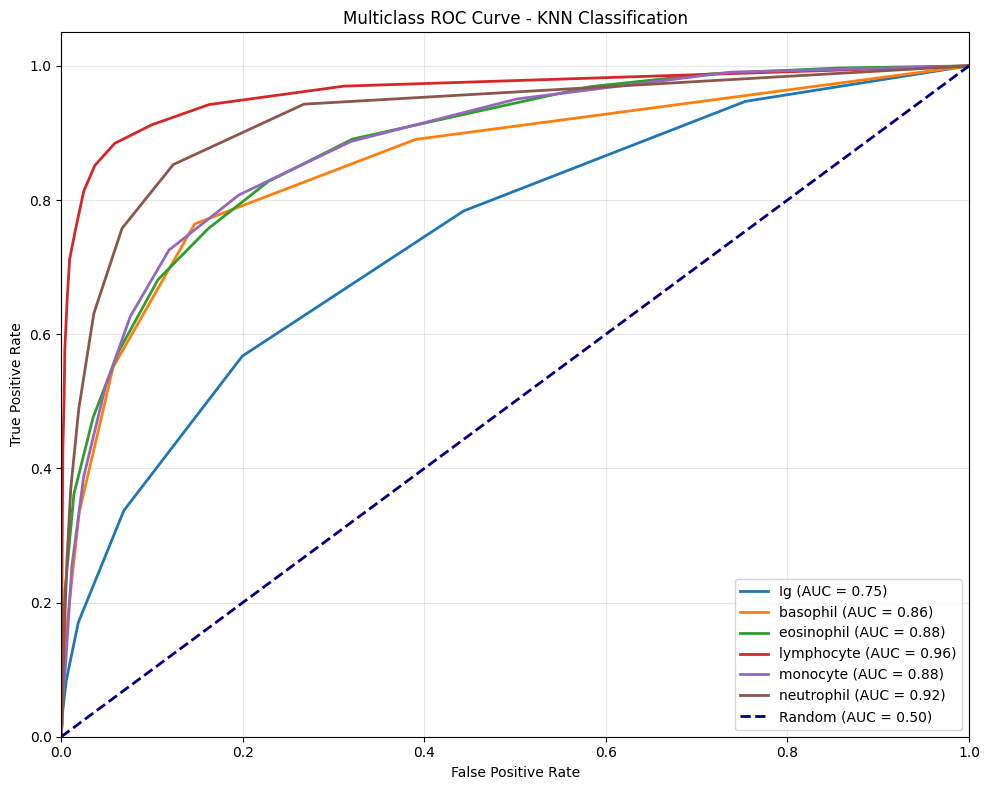

In [31]:
# Get predicted probabilities for each class
y_pred_proba = knn.predict_proba(X_test) 

# Check if y_test contains strings or integers
if isinstance(y_test.iloc[0] if hasattr(y_test, 'iloc') else y_test[0], str):
    # If y_test contains strings, use them directly
    unique_classes = sorted(set(y_test))
    # Create mapping for consistent ordering
    class_to_num = {cls: i for i, cls in enumerate(unique_classes)}
    y_test_numeric = [class_to_num[cls] for cls in y_test]
else:
    # If y_test contains numbers, get unique classes
    unique_classes = sorted(set(y_test))
    y_test_numeric = y_test

# Binarize the true labels using the correct classes
y_test_bin = label_binarize(y_test_numeric, classes=range(len(unique_classes)))

# Handle binary classification case (only 2 classes)
if y_test_bin.shape[1] == 1:
    y_test_bin = np.hstack([1 - y_test_bin, y_test_bin])

plt.figure(figsize=(10, 8))  # Increased size for better legend visibility

# Plot ROC curves for each class
for i in range(len(unique_classes)):
    if i < y_pred_proba.shape[1]:  # Check if class exists in predictions
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
        roc_auc = auc(fpr, tpr)
        
        # Use actual class names if available
        if isinstance(y_test.iloc[0] if hasattr(y_test, 'iloc') else y_test[0], str):
            class_name = unique_classes[i]
        else:
            # Use cell_types if available, otherwise use numeric labels
            try:
                class_name = cell_types[unique_classes[i]]
            except (NameError, IndexError):
                class_name = f'Class {unique_classes[i]}'
        
        plt.plot(fpr, tpr, lw=2, label=f'{class_name} (AUC = {roc_auc:.2f})')

# Plot diagonal line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve - KNN Classification')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


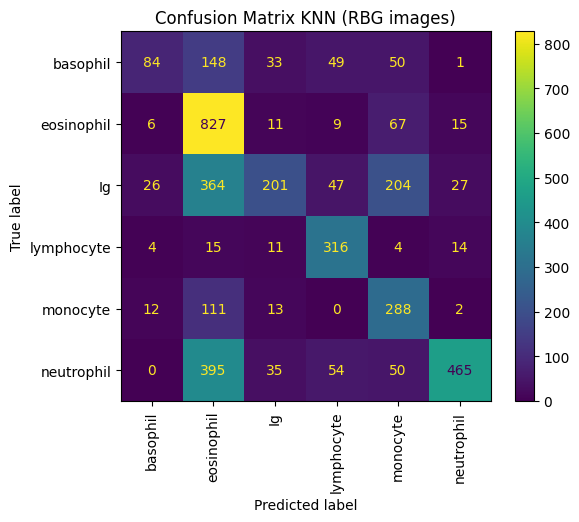

In [32]:
# Get the sorted list of unique labels
class_labels = cell_types
# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=cell_types)
# Create the display object
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

# Plot the display object
disp.plot(xticks_rotation=90)

# Add a title and show the plot
plt.title('Confusion Matrix KNN (RBG images)')

plt.show()

The confusion matrix doesn't look the best. There are lots of false positives. especially with the eosinophils and monocytes

In [13]:
# Create the adjacency matrix
knn_adjacency_matrix = kneighbors_graph(X, n_neighbors=nk, mode='connectivity', include_self=False)
# Create a graph object from the adjacency matrix
knn_graph = nx.from_scipy_sparse_array(knn_adjacency_matrix)

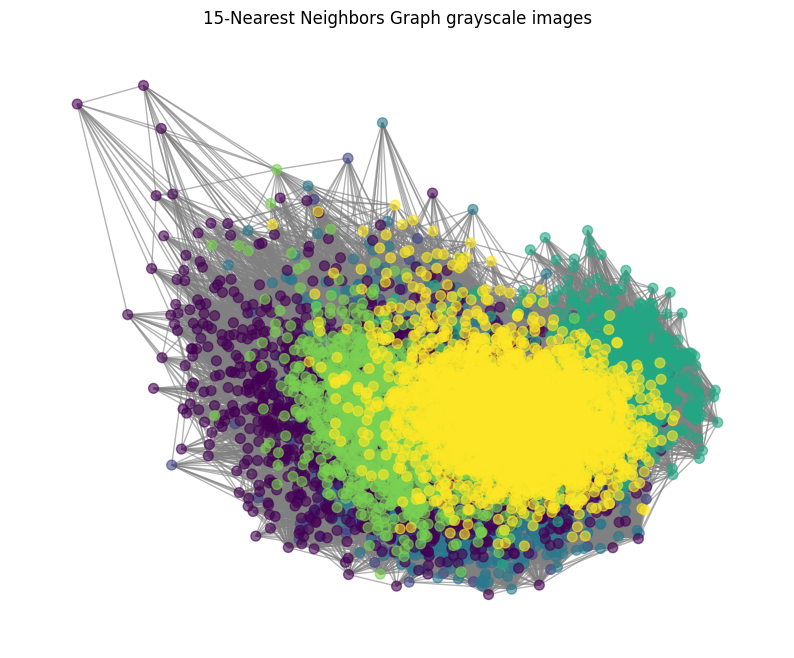

In [14]:
# Reduce X to 2D for plotting
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

plt.figure(figsize=(10, 8))

# Draw the graph using 2D positions
nx.draw_networkx(
    knn_graph,
    pos={i: X_2d[i] for i in range(len(X_2d))},  # Map node index to 2D position
    node_size=50,
    node_color=y.astype('category').cat.codes,  # Convert cell type to integer for coloring
    edge_color='gray',
    alpha=0.6,
    with_labels=False
)

plt.title('15-Nearest Neighbors Graph grayscale images')
plt.axis('off')
plt.show()

Some cell types have better results than others. As we can see from this graph, their are 5 visual areas not 6. The confusion matrix and classification report do not show the best results. lets try another model

Next We will try random forest Classifier modeling with the RBG images.

In [36]:
# Trying a different model - Random Forest Classifier
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train, y_train)
# evaluating the model with the test set
y_pred = rfc.predict(X_test)
print("Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Evaluation:
Accuracy: 0.7941

Classification Report:
              precision    recall  f1-score   support

          Ig       0.61      0.82      0.70       869
    basophil       0.77      0.42      0.55       365
  eosinophil       0.90      0.93      0.91       935
  lymphocyte       0.85      0.80      0.82       364
    monocyte       0.88      0.39      0.54       426
  neutrophil       0.87      0.95      0.91       999

    accuracy                           0.79      3958
   macro avg       0.81      0.72      0.74      3958
weighted avg       0.81      0.79      0.78      3958



K-Fold Mean Accuracy Score: 0.8001
K-Fold Standard Deviation: 0.0075


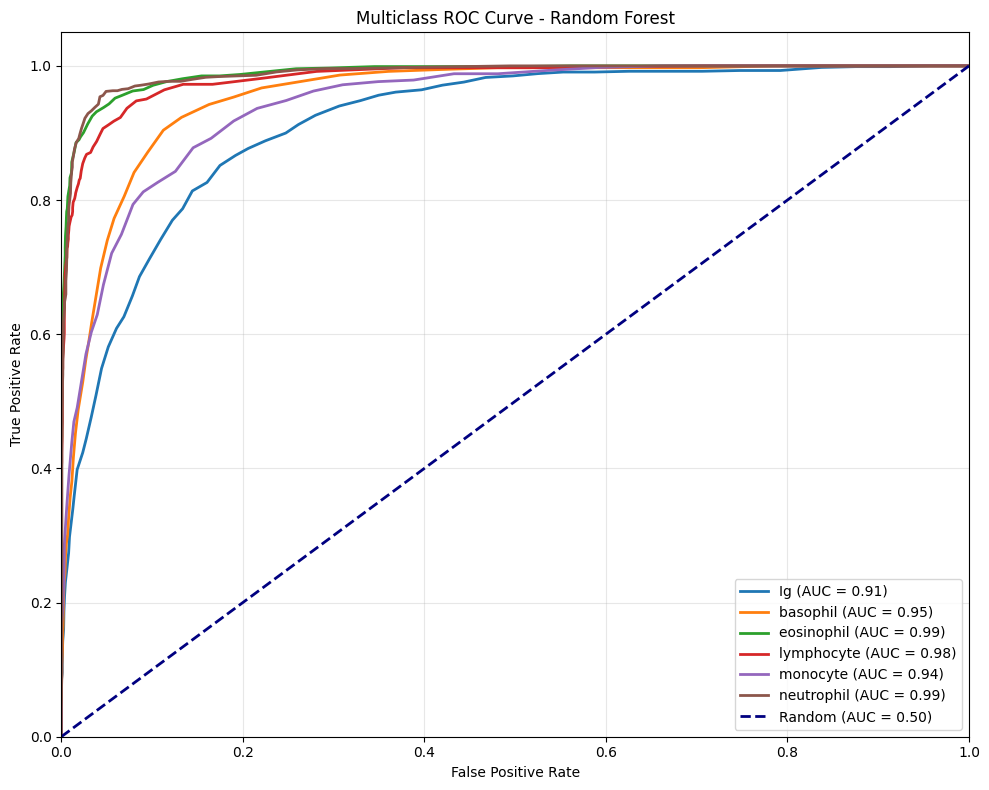

In [ ]:
# Perform K-Fold cross validation on Random Forest model
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Handle y encoding for cross-validation
if isinstance(y.iloc[0], str):  # If y contains strings
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    y_for_cv = le.fit_transform(y)
else:
    y_for_cv = y

cv_scores = cross_val_score(rfc, X, y_for_cv, cv=kf, scoring='accuracy')

print(f"K-Fold Mean Accuracy Score: {cv_scores.mean():.4f}") 
print(f"K-Fold Standard Deviation: {cv_scores.std():.4f}")

# Get predicted probabilities for each class
y_pred_proba = rfc.predict_proba(X_test) 

# Handle label encoding for ROC curves
if isinstance(y_test.iloc[0] if hasattr(y_test, 'iloc') else y_test[0], str):
    unique_classes = sorted(set(y_test))
    class_to_num = {cls: i for i, cls in enumerate(unique_classes)}
    y_test_numeric = [class_to_num[cls] for cls in y_test]
else:
    unique_classes = sorted(set(y_test))
    y_test_numeric = y_test

# Binarize the true labels using numeric classes
y_test_bin = label_binarize(y_test_numeric, classes=range(len(unique_classes)))

# Handle binary classification case
if y_test_bin.shape[1] == 1:
    y_test_bin = np.hstack([1 - y_test_bin, y_test_bin])

plt.figure(figsize=(10, 8))

# Plot ROC curves for each class
for i in range(len(unique_classes)):
    if i < y_pred_proba.shape[1]:
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
        roc_auc = auc(fpr, tpr)
        
        # Get class name
        if isinstance(y_test.iloc[0] if hasattr(y_test, 'iloc') else y_test[0], str):
            class_name = unique_classes[i]
        else:
            try:
                class_name = cell_types[unique_classes[i]]
            except (NameError, IndexError):
                class_name = f'Class {unique_classes[i]}'
        
        plt.plot(fpr, tpr, lw=2, label=f'{class_name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve - Random Forest')  # Updated title
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


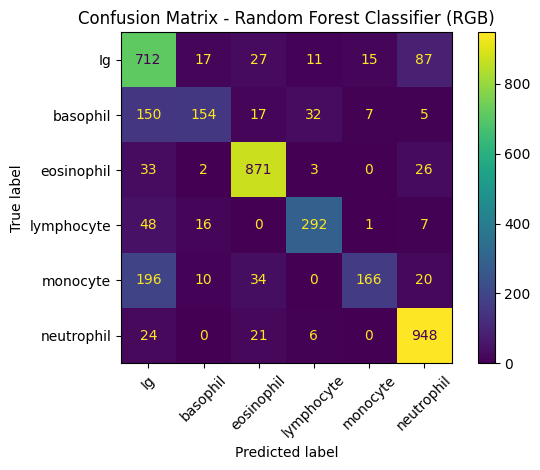

In [38]:
# Create confusion matrix (simplified approach)
cm = confusion_matrix(y_test, y_pred)
unique_test_labels = sorted(set(y_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_test_labels)

# Plot the confusion matrix
disp.plot(xticks_rotation=45)  # Changed to 45 for better readability
plt.title('Confusion Matrix - Random Forest Classifier (RGB)')  
plt.tight_layout()
plt.show()


Random forest preforms better than KNN. The main issue is classifing Ig cells.

Now we will try using a neuro net with CNN

In [41]:
X = np.stack(all_cells_df['img_data'].values)
y, cells = pd.factorize(all_cells_df['cell_type'], sort=True)

In [42]:
# Reshape for CNN: (samples, height, width, channels)
img_size = int(np.sqrt(X.shape[1] / 3))
X_cnn = X.reshape(-1, img_size, img_size, 3).astype('float32') / 255.0

# Train/val/test split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_cnn, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}, Test shape: {X_test.shape}")


Train shape: (9234, 100, 100, 3), Val shape: (1979, 100, 100, 3), Test shape: (1979, 100, 100, 3)


In [43]:
cells = list(cells)
print('Unique cell types:', cells)

Unique cell types: ['Ig', 'basophil', 'eosinophil', 'lymphocyte', 'monocyte', 'neutrophil']


In [44]:
# Class weights
cw = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(cw))
print("Calculated class weights:", class_weights)

Calculated class weights: {0: np.float64(0.7596248766041461), 1: np.float64(1.8042203985932004), 2: np.float64(0.7053162236480294), 3: np.float64(1.8105882352941176), 4: np.float64(1.5482897384305836), 5: np.float64(0.6607986260197509)}


In [50]:
# Small CNN
def create_cnn():
    model = keras.Sequential([
        layers.Input(shape=(img_size, img_size, 3)),
        
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),
        
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),
        
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),
        
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        
        layers.Dense(len(cells), activation='softmax')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = create_cnn()

# Callbacks
early = callbacks.EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

# Train
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early, reduce_lr],
    verbose=1
)

# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")


Epoch 1/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 85s 569ms/step - accuracy: 0.7507 - loss: 0.7318 - val_accuracy: 0.0920 - val_loss: 13.7156 - learning_rate: 0.0010
Epoch 2/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 83s 572ms/step - accuracy: 0.8691 - loss: 0.3682 - val_accuracy: 0.0920 - val_loss: 85.3759 - learning_rate: 0.0010
Epoch 3/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 82s 567ms/step - accuracy: 0.8926 - loss: 0.2935 - val_accuracy: 0.0920 - val_loss: 241.7697 - learning_rate: 0.0010
Epoch 4/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 99s 681ms/step - accuracy: 0.9176 - loss: 0.2310 - val_accuracy: 0.0920 - val_loss: 539.3738 - learning_rate: 0.0010
Epoch 5/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 100s 687ms/step - accuracy: 0.9201 - loss: 0.2258 - val_accuracy: 0.1076 - val_loss: 1365.4849 - learning_rate: 0.0010
Epoch 6/100
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 666ms/step - accuracy: 0.8623 - loss: 0.4055
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
145/145 ━━━━━━━━━━━━━━━━━━━━ 100s 692ms/step 


Classification Report:
              precision    recall  f1-score   support

          Ig       0.94      0.79      0.86       435
    basophil       0.95      0.95      0.95       182
  eosinophil       0.99      0.99      0.99       468
  lymphocyte       0.79      0.98      0.87       182
    monocyte       0.76      0.91      0.83       213
  neutrophil       0.97      0.95      0.96       499

    accuracy                           0.92      1979
   macro avg       0.90      0.93      0.91      1979
weighted avg       0.93      0.92      0.92      1979



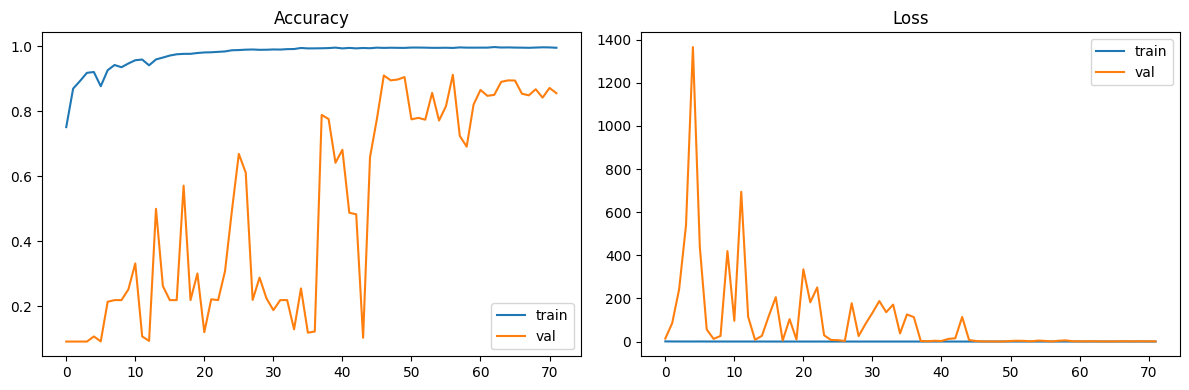

In [51]:
# Report
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=cells))

# Plot history
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.legend()
plt.tight_layout()
plt.show()

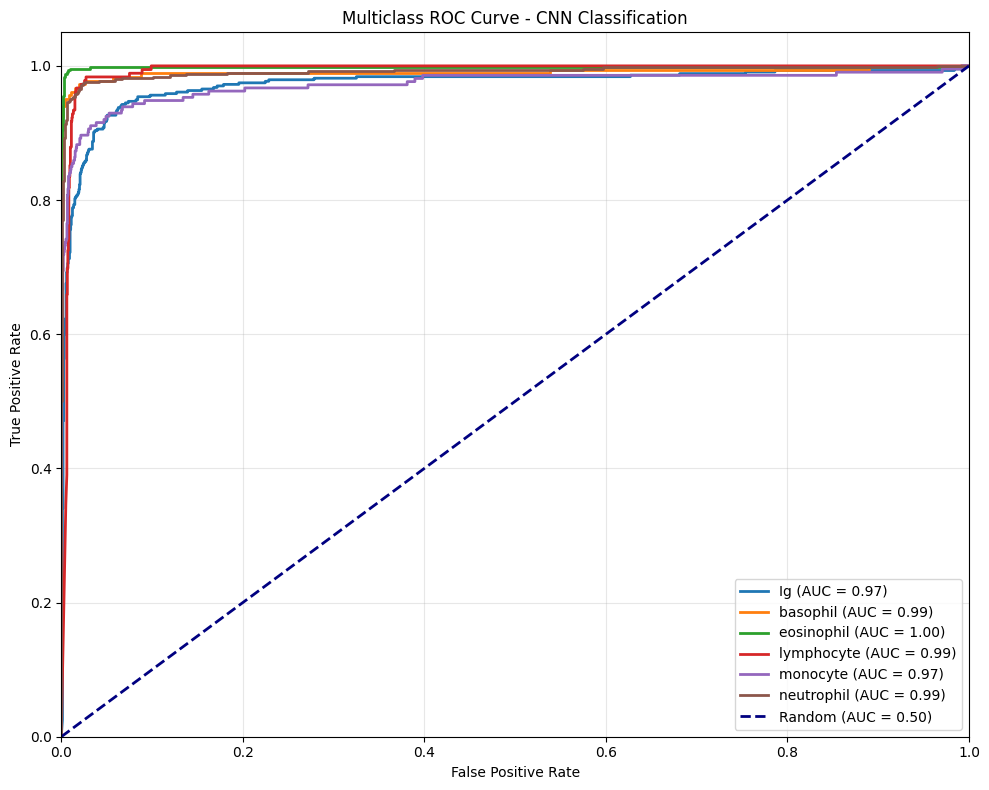

In [52]:
# Get predicted probabilities for each class
y_pred_proba = model.predict(X_test, verbose=0) 

# Binarize the true labels using the correct classes
y_test_bin = label_binarize(y_test, classes=range(len(cells))) 

# Handle binary classification case (only 2 classes)
if y_test_bin.shape[1] == 1:
    y_test_bin = np.hstack([1 - y_test_bin, y_test_bin])

plt.figure(figsize=(10, 8))

# Plot ROC curves for each class
for i, class_name in enumerate(cells): 
    if i < y_pred_proba.shape[1]:  
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{class_name} (AUC = {roc_auc:.2f})')

# Plot diagonal line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve - CNN Classification') 
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

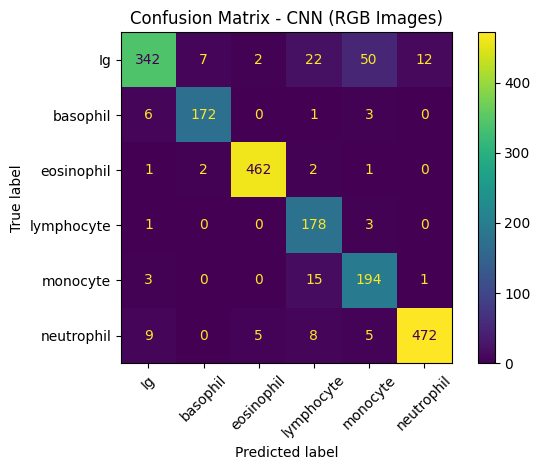

In [53]:
# Compute the confusion matrix using predictions from CNN
cm = confusion_matrix(y_test, y_pred)  

# Create the display object
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cells) 

# Plot the display object
disp.plot(xticks_rotation=45)

# Add a title and show the plot
plt.title('Confusion Matrix - CNN (RGB Images)') 
plt.tight_layout()
plt.show()


In [54]:
#export the nueronet model
model.save('wbc_recognition_model.keras')
